In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

/tmp/ipykernel_2942679/1788881870.py:12: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


In [2]:
def intersection_profile(H, update_every = 1):
    """
    compute the intersection profile of a hypergraph H
    The entry r_{ijk} is the number of times that an edge of size i intersects with a preceding edge of size j on k nodes.
    """
    timesteps = len(H.edges)
    r = defaultdict(int)
    edge_size_dict = defaultdict(int)

    # initialize an empty array that will store the sum of intersections of size k
    R = np.zeros(shape = (timesteps // update_every + 1, k_max), dtype = int)

    for eid in H.edges:
        # first, sample e
        e = H.edges.members(eid)
        e_size = len(e)
        
        # next, we'll consider all the preceding edges that intersect with e and count their intersections. 
        de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
        for nb in de:
            nb_size = len(nb)
            k = len(e.intersection(nb))
            r[(e_size, nb_size, k)] += 1
        
        # then, separately, we'll consider all the edges that *don't* intersect with e 
        # these need to be preceding edges
        # this is handled by constructing edge_size_dict as we go: only the sizes of preceding edges are in there. 
        neighbor_sizes = [len(x) for x in de]
        nb_size_cnt = Counter(neighbor_sizes)
        for j, mj in edge_size_dict.items():
            r[(e_size, j, 0)] += mj - nb_size_cnt[j]
        
        if (eid % update_every) == 0:
            for k in range(k_max):
                R[eid//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
        edge_size_dict[e_size] += 1
        
    return r, R

def approximation(k_max, pars):
    MC = m.MatrixConstructor(k_max, pars)
    M = MC.matrix_of_linear_map()
    EV = np.linalg.eig(M)
    print(f"Leading eigenvalue = {np.max(np.real(EV[0])):.3f}")
    v = np.abs(EV[1][:, np.argmax(np.real(EV[0]))])
    T = m.vec_to_tensor(v, k_max)
    
    return M, T

In [3]:
k_max = 10
pars = {
    "eta"   : 0.4, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][2] = 1
pars["gamma"][0:2] = 1/2

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

In [4]:
timesteps = int(5e5)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for cc in range(timesteps): 
    H.sample_edge(eta, beta, gamma, True)

In [5]:
r, R = intersection_profile(H)

In [6]:
M, T = approximation(k_max, pars)
T_empirical = np.array([[[r[(i, j, k)] for k in range(k_max)] for j in range(k_max)] for i in range(k_max)])

/home/pchodrow/HyperGraph/code/src/analytic-intersection-asymptotics.py:61: RuntimeWarning: invalid value encountered in divide
  S2_kyljh = binom(H, K)*binom(L - H, Y - K)/binom(L, Y)


Leading eigenvalue = 0.999


The conditional distributions of the edge sizes given the intersections appear to be very good: 

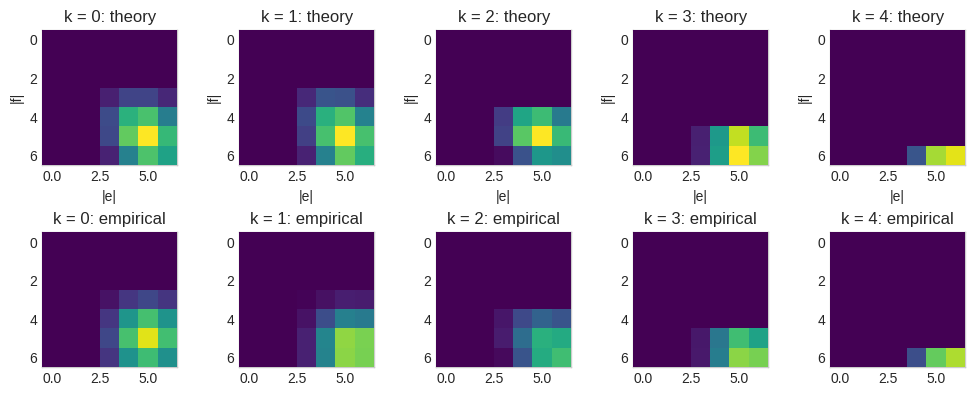

In [7]:
# slices of T line up pretty well with the empirical values, but the scales are off...

panels = 5
show_up_to = 7

fig, ax = plt.subplots(2, panels, figsize = (2*panels, 4))


# so the conditional distributions of i and j given the intersection size k look really good. 
# there is something around magnitude of each size that is off, though. 
# could this be related to handling the r_i terms in some way when computing with this matrix?

for k in range(panels):
    
    to_plot = T[:,:,k] / T[:,:,k].sum()
    to_plot_1 = T_empirical[:,:,k] / T_empirical[:,:,k].sum()
    
    vmax = max(to_plot.max(), to_plot_1.max())
    
    ax[ 0, k].imshow(to_plot[0:show_up_to, 0:show_up_to], cmap = "viridis", zorder = 10, vmax = vmax, interpolation = "none")
    ax[ 0, k].set(title = f"k = {k}: theory")
    ax[0, k].set(xlabel = "|e|", ylabel = "|f|")
    
    ax[ 1, k].imshow(to_plot_1[0:show_up_to, 0:show_up_to], cmap = "viridis", zorder = 10, vmax = vmax, interpolation = "none")
    ax[ 1, k].set(title = f"k = {k}: empirical")
    ax[0, k].set(xlabel = "|e|", ylabel = "|f|")
    
plt.tight_layout()

However, the marginal distributions of edge sizes are off by an order of magnitude or so: 

[Text(0.5, 0, 'k'), Text(0, 0.5, '$P(|e\\cap f| = k)$')]

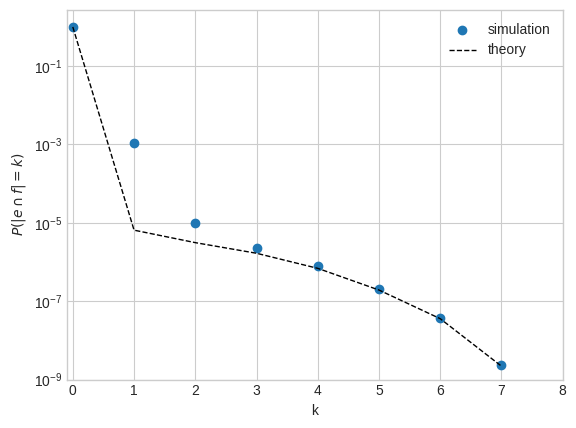

In [8]:
empirical_prop = T_empirical.sum(axis = (0, 1)) / T_empirical.sum()
theory_prop    = T.sum(axis = (0,1))
theory_prop    = theory_prop / theory_prop[0]
theory_prop[1:] = theory_prop[1:] / timesteps 
ix = empirical_prop > 0


plt.scatter(np.array(range(k_max))[ix], empirical_prop[ix], label = "simulation")
plt.plot(np.array(range(k_max))[ix], theory_prop[ix], label = "theory", color = "black", linewidth = 1, linestyle = "dashed")
plt.legend()

plt.semilogy()
plt.ylim(1e-9)
plt.xlim(-0.1, 8)
plt.gca().set(xlabel = "k", ylabel = r"$P(|e\cap f| = k)$")

In [9]:
MC = m.MatrixConstructor(k_max, pars)

In [10]:
A = MC.A
B = MC.B

In [11]:
T.sum(axis = (0,1))

array([1.07216234e+00, 3.48987811e+00, 1.67622181e+00, 8.97650652e-01,
       3.70010594e-01, 1.03381469e-01, 1.92073465e-02, 1.17823526e-03,
       0.00000000e+00, 0.00000000e+00])

Leading eigenvalue = 0.999


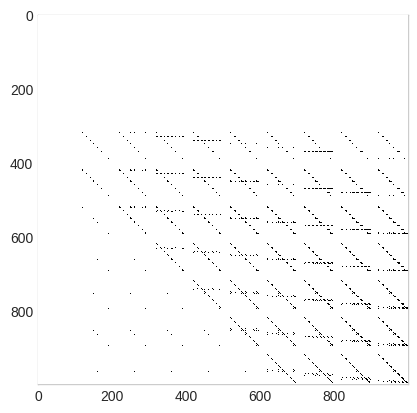

In [12]:
M, T = approximation(k_max, pars)
plt.imshow(M > 0, zorder = 10, interpolation = 'none')